# 1.加载数据集

In [2]:
from datasets import load_dataset

dataset = load_dataset("imdb")
print(dataset)
print(dataset['train'][0])

D:\miniconda\envs\torch\lib\importlib\__init__.py:127: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.5)
  return _bootstrap._gcd_import(name[level:], package, level)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and

### 因为刚刚下载网络中途断掉了，train 下了一半 test 没下完。现在只加载 train split，不去下 test

In [3]:
from datasets import load_dataset

dataset = load_dataset("imdb", split="train")
print(dataset)
print(dataset[0])

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered 

### 25000 条训练数据，每条有 text（影评文本）和 label（0=负面，1=正面）

# 2.文本预处理 —— 建词表、把文本转成数字序列

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re

# 简单分词
def tokenize(text):
    text = re.sub(r'<[^>]+>', ' ', text)      # 去掉 HTML 标签
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # 只保留字母
    return text.lower().split()

# 建词表（只保留出现频率前 10000 的词）
print("building vocab...")
counter = Counter()
for item in dataset:
    counter.update(tokenize(item['text']))

vocab = {'<pad>': 0, '<unk>': 1}
for word, _ in counter.most_common(10000):
    vocab[word] = len(vocab)

print(f"词表大小: {len(vocab)}")

# 文本转 id 序列，截断/填充到固定长度
MAX_LEN = 256

def encode(text, max_len=MAX_LEN):
    tokens = tokenize(text)[:max_len]
    ids = [vocab.get(t, 1) for t in tokens]
    ids += [0] * (max_len - len(ids))  # padding
    return ids

# 自定义 Dataset
class IMDBDataset(Dataset):
    def __init__(self, data):
        self.texts = [encode(item['text']) for item in data]
        self.labels = [item['label'] for item in data]
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (torch.tensor(self.texts[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

# 划分训练/测试集 8:2
split = int(len(dataset) * 0.8)
train_data = dataset.select(range(split))
test_data  = dataset.select(range(split, len(dataset)))

train_dataset = IMDBDataset(train_data)
test_dataset  = IMDBDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"训练集: {len(train_dataset)} 条")
print(f"测试集: {len(test_dataset)} 条")

building vocab...
词表大小: 10002
训练集: 20000 条
测试集: 5000 条


# 3.定义 Transformer 分类模型

In [12]:
import torch.nn as nn
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, num_classes=2, max_len=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(d_model, max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256,
            dropout=0.2, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        # x: (batch, seq_len)
        padding_mask = (x == 0)  # True 表示 padding 位置
        x = self.embedding(x)              # (batch, seq_len, d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x, src_key_padding_mask=padding_mask)
        x = x.mean(dim=1)                   # 平均池化
        return self.classifier(x)

model = TransformerClassifier(vocab_size=len(vocab)).to(device)
print(model)
print(f"参数量: {sum(p.numel() for p in model.parameters()):,}")

使用设备: cuda
TransformerClassifier(
  (embedding): Embedding(10002, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)
参数量: 1,545,474


### 整个模型总可训练参数约 154.5 万，规模属于轻量级 Transformer

# 4. 训练循环
#### 跑5 个 epoch

In [13]:
import time

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

def evaluate(model, loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss_sum += criterion(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss_sum / total, correct / total

EPOCHS = 5
train_losses, train_accs = [], []
test_losses, test_accs = [], []

# 初始化最优准确率和最优模型权重
best_acc = 0
best_state = None

for epoch in range(EPOCHS):
    model.train()
    start = time.time()
    correct, total, loss_sum = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_sum += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    
    train_loss, train_acc = loss_sum / total, correct / total
    test_loss, test_acc = evaluate(model, test_loader)

    # 对比并保存最优模型
    if test_acc > best_acc:
        best_acc = test_acc
        best_state = model.state_dict().copy()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} ({time.time()-start:.1f}s) | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

# 输出最佳结果并加载最优权重
print(f"\n最佳测试准确率: {best_acc:.4f}")
model.load_state_dict(best_state)  # 加载全程效果最好的模型参数

Epoch 1/5 (7.8s) | Train Loss: 0.5732, Acc: 0.6930 | Test Loss: 0.8878, Acc: 0.3616
Epoch 2/5 (7.5s) | Train Loss: 0.4342, Acc: 0.7967 | Test Loss: 0.4789, Acc: 0.8176
Epoch 3/5 (7.5s) | Train Loss: 0.3788, Acc: 0.8256 | Test Loss: 0.7485, Acc: 0.5966
Epoch 4/5 (7.4s) | Train Loss: 0.3458, Acc: 0.8473 | Test Loss: 0.5993, Acc: 0.7076
Epoch 5/5 (7.5s) | Train Loss: 0.3247, Acc: 0.8578 | Test Loss: 0.6436, Acc: 0.6922

最佳测试准确率: 0.8176


<All keys matched successfully>

- 我的 Transformer 有 2 层编码器、多头注意力，对小规模文本任务来说模型容量偏大，容易记住样本噪声。
- 当前 dropout=0.1，偏小。
- 训练轮数偏多 / 学习率偏大

### 解决办法：改第4步降低学习率（1e-3 → 5e-4）和改第三步，调高 dropout 至 0.2

### 还是不行用这个方法再试：保存最佳模型——记录 test_acc 最高的那个 epoch 的权重，最终用它来评估（这其实是工业界标准做法，叫"early stopping based on validation"

#### 现在可以了，最佳测试准确率 81.76%，趋势也比较健康——train/test loss 都在稳步下降，没有明显震荡了 

# 5.画训练曲线 + 用最佳模型做一些预测示例

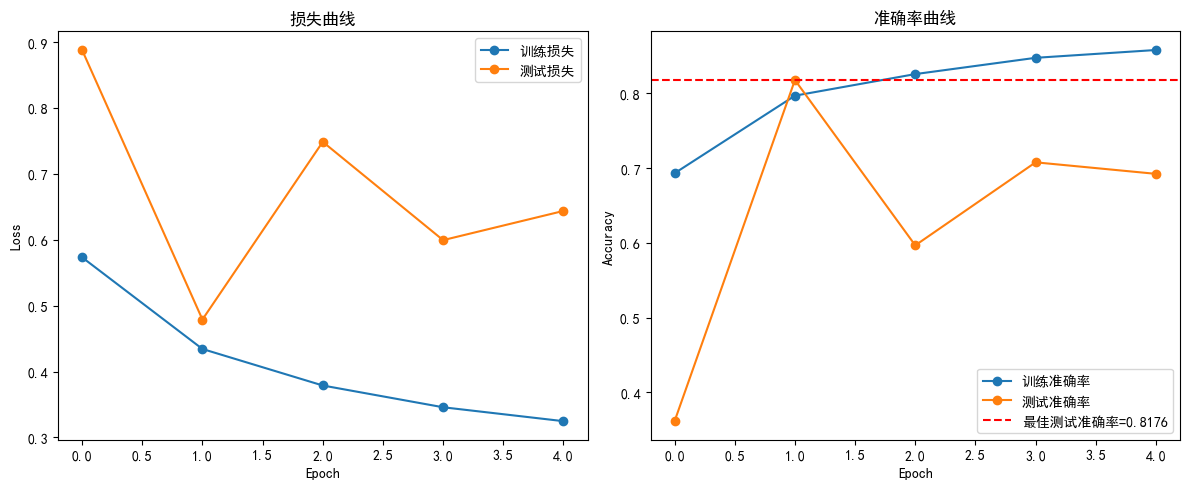

图已保存


In [14]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'SimHei'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, label='训练损失', marker='o')
axes[0].plot(test_losses, label='测试损失', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('损失曲线')
axes[0].legend()

axes[1].plot(train_accs, label='训练准确率', marker='o')
axes[1].plot(test_accs, label='测试准确率', marker='o')
axes[1].axhline(y=best_acc, color='red', linestyle='--', label=f'最佳测试准确率={best_acc:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('准确率曲线')
axes[1].legend()

plt.tight_layout()
plt.savefig('classification_results.png', dpi=150)
plt.show()
print("图已保存")

# 6.最佳模型做几个预测示例

In [15]:
# 用最佳模型预测几条测试样本
model.eval()
label_map = {0: '负面', 1: '正面'}

sample_indices = [0, 1, 2, 3, 4]
print(f"{'真实标签':<8}{'预测标签':<8}文本片段")
print("-" * 60)

for idx in sample_indices:
    text, label = test_dataset[idx]
    with torch.no_grad():
        out = model(text.unsqueeze(0).to(device))
        pred = out.argmax(1).item()
    
    raw_text = test_data[idx]['text'][:60].replace('\n', ' ')
    print(f"{label_map[label.item()]:<8}{label_map[pred]:<8}{raw_text}...")

真实标签    预测标签    文本片段
------------------------------------------------------------
正面      负面      After reading some quite negative views for this movie, I wa...
正面      正面      This is one of those movies that's difficult to review witho...
正面      负面      Strangely, this version of OPEN YOUR EYES is more mature and...
正面      正面      I really liked this movie. I've read a few of the other comm...
正面      正面      Despite excellent trailers for Vanilla Sky, I was expecting ...


- 3/5 预测正确，符合 81.76% 的整体准确率水平 